In [1]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

!ls /content/drive/
%cd "/content/drive/My Drive/HW1_113064525_徐綉惠/"
!unzip eye.zip -d "./eye_dataset/"
!ls "./eye_dataset/"


MyDrive
/content/drive/My Drive/HW1_113064525_徐綉惠
Archive:  eye.zip
   creating: ./eye_dataset/eye/
  inflating: ./eye_dataset/eye/data.npy  
  inflating: ./eye_dataset/eye/label.npy  
eye


In [3]:

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms
import random
import torch.nn as nn
import torch.optim as optim
import copy
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import os
from PIL import Image


## Step 1. Custom Dataset Class

In [4]:

class Eye_Dataset(Dataset):
    def __init__(self, data_path, label_path, transform=None):
        # load data and labels
        self.data = np.load(data_path)
        self.labels = np.load(label_path)
        self.transform = transform

    def __len__(self):
        # the total number of images
        return len(self.data)

    def __getitem__(self, idx):
        # get the image and label at the specified index
        image = self.data[idx]
        label = self.labels[idx]

        # apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

# define the transformation of images
transform = transforms.Compose([
    # convert NumPy array to tensor and normalize to [0, 1]
    transforms.ToTensor(),
    # convert the data type from float64 to float32
    transforms.ConvertImageDtype(torch.float32)
])


In [5]:

# PyTorch Dataset Class
dataset = Eye_Dataset(data_path='./eye_dataset/eye/data.npy', label_path='./eye_dataset/eye/label.npy', transform=transform)

# set the seed for reproducibility
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)


## Step 2. CNN-Based AE and VAE

In [6]:

class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # Output: 16 x 25 x 25
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Output: 32 x 13 x 13
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: 64 x 7 x 7
            nn.ReLU(),
            # nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # Output: 128 x 4 x 4
            # nn.ReLU(),
            # nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # Output: 256 x 2 x 2
            # nn.ReLU()
        )

        # decoder
        self.decoder = nn.Sequential(
            # nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, output_padding=0), # Output: 128 x 4 x 4
            # nn.ReLU(),
            # nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=2, output_padding=1),  # Output: 64 x 7 x 7
            # nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=2, output_padding=1), # Output: 32 x 13 x 13
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=2, output_padding=1), # Output: 16 x 25 x 25
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1, output_padding=0),  # Output: 3 x 50 x 50
            nn.Sigmoid()  # use Sigmoid function because the input images are normalized between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [7]:

# instantiate the model
AE_before_train = AutoEncoder()

# show the model architecture
print(AE_before_train)

# make a deep copy of the AE model to keep an untrained version
AE_after_train = copy.deepcopy(AE_before_train)


AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [8]:

class VariationalAutoEncoder(nn.Module):
    def __init__(self, latent):
        super(VariationalAutoEncoder, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # Output: 16 x 25 x 25
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Output: 32 x 13 x 13
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: 64 x 7 x 7
            nn.ReLU(),
            # nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # Output: 128 x 4 x 4
            # nn.ReLU(),
            # nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # Output: 256 x 2 x 2
            # nn.ReLU()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent)
        self.fc_decode = nn.Linear(latent, 64 * 7 * 7)
        # self.fc_mu = nn.Linear(256 * 2 * 2, latent)
        # self.fc_logvar = nn.Linear(256 * 2 * 2, latent)
        # self.fc_decode = nn.Linear(latent, 256 * 2 * 2)

        # decoder
        self.decoder = nn.Sequential(
            # nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, output_padding=0), # Output: 128 x 4 x 4
            # nn.ReLU(),
            # nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=2, output_padding=1),  # Output: 64 x 7 x 7
            # nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=2, output_padding=1), # Output: 32 x 13 x 13
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=2, output_padding=1), # Output: 16 x 25 x 25
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1, output_padding=0),  # Output: 3 x 50 x 50
            nn.Sigmoid()  # use Sigmoid function because the input images are normalized between 0 and 1
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        x = x.reshape(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        x = self.fc_decode(z)
        x = x.view(-1, 64, 7, 7)
        # x = x.view(-1, 256, 2, 2)
        x = self.decoder(x)
        return x, mu, logvar


In [9]:

# instantiate the model
VAE_before_train = VariationalAutoEncoder(latent = 128)

# show the model architecture
print(VAE_before_train)

# make a deep copy of the VAE model to keep an untrained version
VAE_after_train = copy.deepcopy(VAE_before_train)


VariationalAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


## Step 3. Train AE Model

In [10]:

def Train_AE(model, dataloader, epochs, lr):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []  # store the training loss for each epoch

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, _ in dataloader:

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)  # store the training loss for current epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

    # save AE model weights
    torch.save(model.state_dict(), 'AutoEncoder_weights.pth')

    # plot learning curve
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('AutoEncoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()


### If you do not wish to train the new model, please skip ahead to the section on loading model weights.

Epoch 1/80, Loss: 0.0170
Epoch 2/80, Loss: 0.0043
Epoch 3/80, Loss: 0.0033
Epoch 4/80, Loss: 0.0027
Epoch 5/80, Loss: 0.0024
Epoch 6/80, Loss: 0.0021
Epoch 7/80, Loss: 0.0020
Epoch 8/80, Loss: 0.0017
Epoch 9/80, Loss: 0.0017
Epoch 10/80, Loss: 0.0016
Epoch 11/80, Loss: 0.0015
Epoch 12/80, Loss: 0.0015
Epoch 13/80, Loss: 0.0014
Epoch 14/80, Loss: 0.0014
Epoch 15/80, Loss: 0.0013
Epoch 16/80, Loss: 0.0012
Epoch 17/80, Loss: 0.0012
Epoch 18/80, Loss: 0.0012
Epoch 19/80, Loss: 0.0011
Epoch 20/80, Loss: 0.0010
Epoch 21/80, Loss: 0.0010
Epoch 22/80, Loss: 0.0009
Epoch 23/80, Loss: 0.0009
Epoch 24/80, Loss: 0.0009
Epoch 25/80, Loss: 0.0008
Epoch 26/80, Loss: 0.0008
Epoch 27/80, Loss: 0.0008
Epoch 28/80, Loss: 0.0007
Epoch 29/80, Loss: 0.0009
Epoch 30/80, Loss: 0.0007
Epoch 31/80, Loss: 0.0007
Epoch 32/80, Loss: 0.0008
Epoch 33/80, Loss: 0.0007
Epoch 34/80, Loss: 0.0007
Epoch 35/80, Loss: 0.0007
Epoch 36/80, Loss: 0.0007
Epoch 37/80, Loss: 0.0007
Epoch 38/80, Loss: 0.0007
Epoch 39/80, Loss: 0.

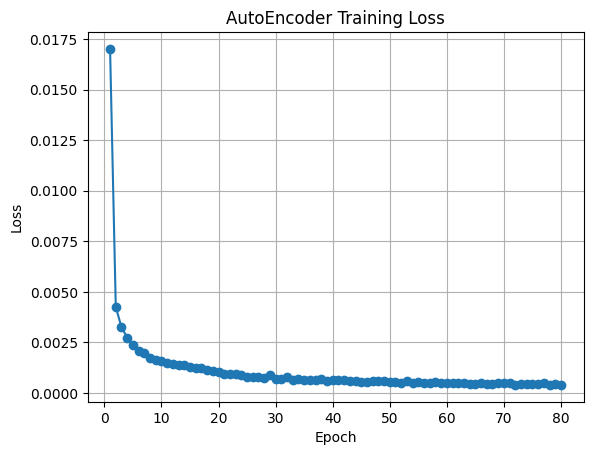

In [12]:

# train the copied AE model
AE_after_train = Train_AE(AE_after_train, dataloader, epochs=80, lr=1e-3)


## Step 3. Train VAE Model

In [11]:

def Train_VAE(model, dataloader, epochs, lr):

    criterion = nn.BCELoss(reduction='sum')  # Binary Cross-Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []  # store the training loss for each epoch

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, _ in dataloader:

            optimizer.zero_grad()
            outputs, mu, logvar = model(images)
            reconstruction_loss = criterion(outputs, images)
            kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = reconstruction_loss + 0.1 * kl_divergence
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)  # store the training loss for current epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

    # save VAE model weights
    torch.save(model.state_dict(), 'VariationalAutoEncoder_weights.pth')

    # plot learning curve
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('Variational AutoEncoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()


### If you do not wish to train the new model, please skip ahead to the section on loading model weights.

Epoch 1/80, Loss: 18783.2274
Epoch 2/80, Loss: 17903.9117
Epoch 3/80, Loss: 17769.0687
Epoch 4/80, Loss: 17687.0015
Epoch 5/80, Loss: 17651.2030
Epoch 6/80, Loss: 17613.5804
Epoch 7/80, Loss: 17582.0077
Epoch 8/80, Loss: 17572.4749
Epoch 9/80, Loss: 17548.6171
Epoch 10/80, Loss: 17533.7328
Epoch 11/80, Loss: 17519.9062
Epoch 12/80, Loss: 17513.9193
Epoch 13/80, Loss: 17488.6839
Epoch 14/80, Loss: 17484.0501
Epoch 15/80, Loss: 17483.4967
Epoch 16/80, Loss: 17474.6992
Epoch 17/80, Loss: 17459.0553
Epoch 18/80, Loss: 17450.4753
Epoch 19/80, Loss: 17441.5094
Epoch 20/80, Loss: 17435.3922
Epoch 21/80, Loss: 17443.0767
Epoch 22/80, Loss: 17428.7230
Epoch 23/80, Loss: 17421.5874
Epoch 24/80, Loss: 17416.1163
Epoch 25/80, Loss: 17414.0888
Epoch 26/80, Loss: 17404.6976
Epoch 27/80, Loss: 17397.1160
Epoch 28/80, Loss: 17400.0566
Epoch 29/80, Loss: 17393.7946
Epoch 30/80, Loss: 17386.2275
Epoch 31/80, Loss: 17391.6469
Epoch 32/80, Loss: 17384.9452
Epoch 33/80, Loss: 17382.8999
Epoch 34/80, Loss: 

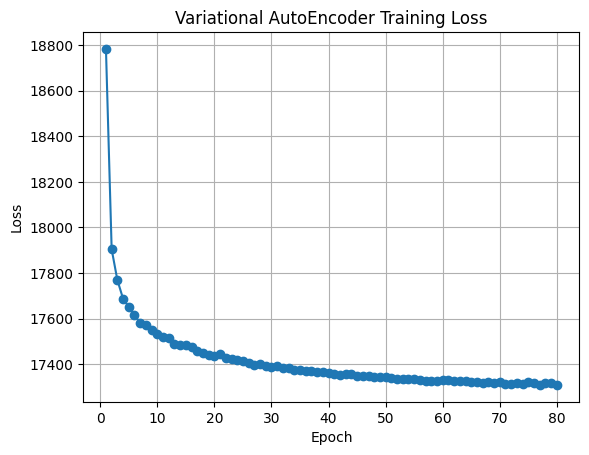

In [13]:

# train the copied VAE model
VAE_after_train = Train_VAE(VAE_after_train, dataloader, epochs=80, lr=1e-3)


## Step 4. Evaluate average PSNR and SSIM

In [14]:

# load the weights back into the models
AE_trained = AutoEncoder()  # recreate AE model architecture
AE_trained.load_state_dict(torch.load('AutoEncoder_weights.pth'))
VAE_trained = VariationalAutoEncoder(latent=128)  # recreate VAE model architecture
VAE_trained.load_state_dict(torch.load('VariationalAutoEncoder_weights.pth'))

# load the dataset
dataset_o = Eye_Dataset(data_path='./eye_dataset/eye/data.npy', label_path='./eye_dataset/eye/label.npy', transform=None)  # ensure the dataset loads original images
dataloader_o = DataLoader(dataset_o, batch_size=1, shuffle=False)


<ipython-input-14-1131ccc12b4b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  AE_trained.load_state_dict(torch.load('AutoEncoder_weights.pth'))
<ipython-input-14-1131ccc1

In [15]:

def Save(image_array, path):
    image = Image.fromarray(image_array)
    image.save(path)


In [16]:

def Evaluate(model, dataloader, image_ids, save_dir):
    model.eval()

    # create directory for reconstructed and original images
    os.makedirs(save_dir, exist_ok=True)
    original_dir = os.path.join(save_dir, "original")
    reconstructed_dir = os.path.join(save_dir, "reconstructed")
    os.makedirs(original_dir, exist_ok=True)
    os.makedirs(reconstructed_dir, exist_ok=True)

    image_id = 1  # start from 1 as the image index range is 1-1476
    saved_images = 0

    PSNR_values = []
    SSIM_values = []

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            img, _ = data
            img = img.to(torch.float32)
            img = img.permute(0, 3, 1, 2)

            output = model(img)
            if isinstance(output, tuple):
                reconstructed_img = output[0]
            else:
                reconstructed_img = output

            # convert to numpy arrays for processing
            reconstructed_img = reconstructed_img.detach().cpu().numpy()
            original_img = img.cpu().numpy()

            # remove batch dimension and transpose to (H, W, C)
            reconstructed_img = reconstructed_img.squeeze(0).transpose(1, 2, 0)
            original_img = original_img.squeeze(0).transpose(1, 2, 0)

            # ensure images are in the correct range for saving
            reconstructed_img = np.clip(reconstructed_img, 0, 1) * 255.0
            original_img = np.clip(original_img, 0, 1) * 255.0

            # convert to uint8 for saving
            reconstructed_img = reconstructed_img.astype(np.uint8)
            original_img = original_img.astype(np.uint8)

            # compute PSNR and SSIM for each image
            PSNR = peak_signal_noise_ratio(original_img, reconstructed_img, data_range=255)
            SSIM = structural_similarity(original_img, reconstructed_img, multichannel=True, data_range=255, win_size=11, channel_axis=-1)

            PSNR_values.append(PSNR)
            SSIM_values.append(SSIM)

            # check if the current image ID is in the specified list
            if image_id in image_ids:
                # save original and reconstructed images
                Save(original_img, os.path.join(original_dir, f"original_{image_id}.png"))
                Save(reconstructed_img, os.path.join(reconstructed_dir, f"reconstructed_{image_id}.png"))
                saved_images += 1

            if saved_images >= 20:  # stop once 20 images have been saved
                break

            image_id += 1

    # calculate average PSNR and average SSIM
    avg_PSNR = np.mean(PSNR_values)
    avg_SSIM = np.mean(SSIM_values)

    return avg_PSNR, avg_SSIM


## Step 5. Save 20 reconstruction results

In [17]:

# define image IDs and save directories for AE and VAE
image_ids = [91, 92, 93, 94, 95, 481, 482, 483, 484, 485, 936, 937, 938, 939, 940, 1446, 1447, 1448, 1449, 1450]
save_dir_AE = 'AE_reconstructions'
save_dir_VAE = 'VAE_reconstructions'

AE_PSNR, AE_SSIM = Evaluate(AE_trained, dataloader_o, image_ids, save_dir_AE)
print(f'AE - Average PSNR: {AE_PSNR}, Average SSIM: {AE_SSIM}')

VAE_PSNR, VAE_SSIM = Evaluate(VAE_trained, dataloader_o, image_ids, save_dir_VAE)
print(f'VAE - Average PSNR: {VAE_PSNR}, Average SSIM: {VAE_SSIM}')


AE - Average PSNR: 34.38919569174138, Average SSIM: 0.9776838202522498
VAE - Average PSNR: 27.383389689848464, Average SSIM: 0.8983440551367994


## Step 6. Add Gaussian noise into the Trained AE and VAE respectively

In [18]:

class AutoEncoder_Noise(nn.Module):
    def __init__(self, original_autoencoder, noise_std):
        super(AutoEncoder_Noise, self).__init__()
        self.encoder = original_autoencoder.encoder
        self.decoder = original_autoencoder.decoder
        self.noise_std = noise_std

    def forward(self, x):
        # encode the input to get the latent vector
        latent_vector = self.encoder(x)

        # add Gaussian noise to the latent vector
        noisy_latent_vector = latent_vector + torch.randn_like(latent_vector) * self.noise_std

        # decode the noisy latent vector to get the output
        output = self.decoder(noisy_latent_vector)
        return output


In [19]:

def Train_AE_Noise(model, dataloader, epochs, lr):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []  # store the training loss for each epoch

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, _ in dataloader:

            optimizer.zero_grad()
            outputs = model(images)  # use clean images here
            loss = criterion(outputs, images)  # compare reconstructions to original images
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)  # store the training loss for current epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

    # save the trained model weights
    torch.save(model.state_dict(), 'AutoEncoder_Noise_weights.pth')

    # plot learning curve
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('AutoEncoder Training Loss with Gaussian Noise in Latent Vector')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()


### If you do not wish to train the new model, please skip ahead to the section on loading model weights.

Epoch 1/80, Loss: 0.0203
Epoch 2/80, Loss: 0.0048
Epoch 3/80, Loss: 0.0038
Epoch 4/80, Loss: 0.0033
Epoch 5/80, Loss: 0.0030
Epoch 6/80, Loss: 0.0027
Epoch 7/80, Loss: 0.0025
Epoch 8/80, Loss: 0.0024
Epoch 9/80, Loss: 0.0022
Epoch 10/80, Loss: 0.0023
Epoch 11/80, Loss: 0.0021
Epoch 12/80, Loss: 0.0019
Epoch 13/80, Loss: 0.0019
Epoch 14/80, Loss: 0.0018
Epoch 15/80, Loss: 0.0017
Epoch 16/80, Loss: 0.0017
Epoch 17/80, Loss: 0.0017
Epoch 18/80, Loss: 0.0017
Epoch 19/80, Loss: 0.0016
Epoch 20/80, Loss: 0.0015
Epoch 21/80, Loss: 0.0016
Epoch 22/80, Loss: 0.0015
Epoch 23/80, Loss: 0.0014
Epoch 24/80, Loss: 0.0014
Epoch 25/80, Loss: 0.0014
Epoch 26/80, Loss: 0.0014
Epoch 27/80, Loss: 0.0013
Epoch 28/80, Loss: 0.0013
Epoch 29/80, Loss: 0.0013
Epoch 30/80, Loss: 0.0013
Epoch 31/80, Loss: 0.0012
Epoch 32/80, Loss: 0.0013
Epoch 33/80, Loss: 0.0013
Epoch 34/80, Loss: 0.0012
Epoch 35/80, Loss: 0.0012
Epoch 36/80, Loss: 0.0012
Epoch 37/80, Loss: 0.0011
Epoch 38/80, Loss: 0.0012
Epoch 39/80, Loss: 0.

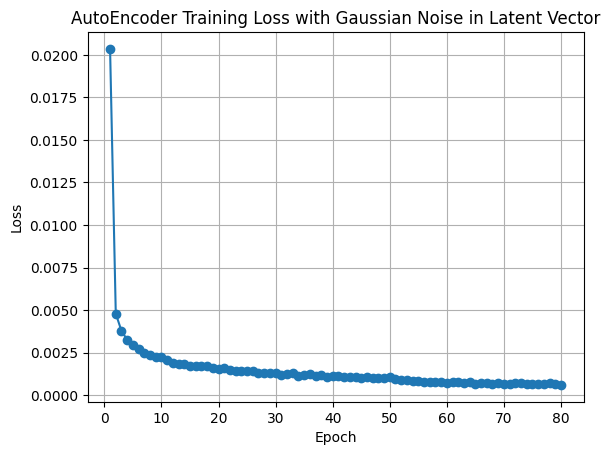

In [20]:

AE_noise = AutoEncoder_Noise(AE_before_train, noise_std=0.5)
Train_AE_Noise(AE_noise, dataloader, epochs=80, lr=1e-3)


In [21]:

class VariationalAutoEncoder_Noise(nn.Module):
    def __init__(self, original_variationalautoencoder, noise_std):
        super(VariationalAutoEncoder_Noise, self).__init__()
        self.encoder = original_variationalautoencoder.encoder
        self.fc_mu = original_variationalautoencoder.fc_mu
        self.fc_logvar = original_variationalautoencoder.fc_logvar
        self.fc_decode = original_variationalautoencoder.fc_decode
        self.decoder = original_variationalautoencoder.decoder
        self.noise_std = noise_std

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        x = x.reshape(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)

        # add Gaussian noise to the latent vector
        noisy_z = z + torch.randn_like(z) * self.noise_std

        x = self.fc_decode(noisy_z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder(x)
        return x, mu, logvar


In [22]:

def Train_VAE_Noise(model, dataloader, epochs, lr):

    criterion = nn.BCELoss(reduction='sum')  # Binary Cross-Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []  # store the training loss for each epoch

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, _ in dataloader:

            optimizer.zero_grad()
            outputs, mu, logvar = model(images)
            reconstruction_loss = criterion(outputs, images)
            kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = reconstruction_loss + 0.1 * kl_divergence
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)  # store the training loss for current epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

    # save VAE model weights
    torch.save(model.state_dict(), 'VariationalAutoEncoder_Noise_weights.pth')

    # plot learning curve
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('Variational AutoEncoder Training Loss with Gaussian Noise in Latent Vector')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()


### If you do not wish to train the new model, please skip ahead to the section on loading model weights.

Epoch 1/80, Loss: 18848.4605
Epoch 2/80, Loss: 18005.7598
Epoch 3/80, Loss: 17839.4388
Epoch 4/80, Loss: 17777.9808
Epoch 5/80, Loss: 17729.5015
Epoch 6/80, Loss: 17702.7679
Epoch 7/80, Loss: 17693.4337
Epoch 8/80, Loss: 17669.1259
Epoch 9/80, Loss: 17652.6770
Epoch 10/80, Loss: 17640.8626
Epoch 11/80, Loss: 17632.2151
Epoch 12/80, Loss: 17609.1465
Epoch 13/80, Loss: 17597.2006
Epoch 14/80, Loss: 17594.9143
Epoch 15/80, Loss: 17582.5203
Epoch 16/80, Loss: 17588.4312
Epoch 17/80, Loss: 17579.2194
Epoch 18/80, Loss: 17562.9830
Epoch 19/80, Loss: 17562.7012
Epoch 20/80, Loss: 17554.7858
Epoch 21/80, Loss: 17550.4182
Epoch 22/80, Loss: 17539.8686
Epoch 23/80, Loss: 17544.8432
Epoch 24/80, Loss: 17537.8531
Epoch 25/80, Loss: 17528.7257
Epoch 26/80, Loss: 17525.6586
Epoch 27/80, Loss: 17524.8894
Epoch 28/80, Loss: 17519.7568
Epoch 29/80, Loss: 17514.2649
Epoch 30/80, Loss: 17514.5961
Epoch 31/80, Loss: 17505.8855
Epoch 32/80, Loss: 17503.1796
Epoch 33/80, Loss: 17506.7202
Epoch 34/80, Loss: 

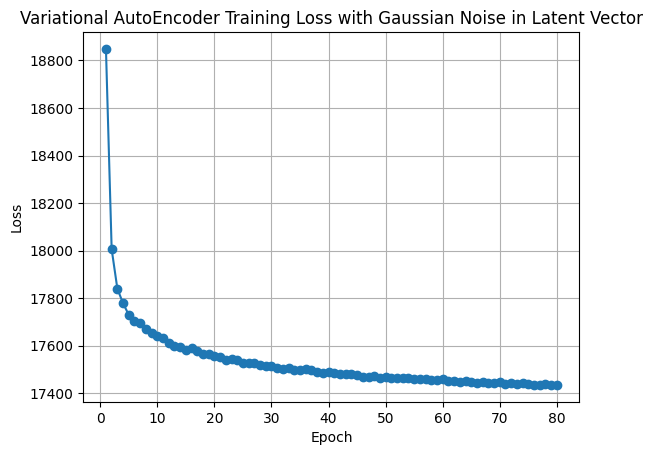

In [23]:

VAE_noise = VariationalAutoEncoder_Noise(VAE_before_train, noise_std=0.5)
Train_VAE_Noise(VAE_noise, dataloader, epochs=80, lr=1e-3)


In [24]:

# load the weights back into the models
AE_trained_noise = AutoEncoder_Noise(AE_before_train, noise_std=0.5)  # recreate AE model architecture
AE_trained_noise.load_state_dict(torch.load('AutoEncoder_Noise_weights.pth'))
VAE_trained_noise = VariationalAutoEncoder_Noise(VAE_before_train, noise_std=0.5)  # recreate VAE model architecture
VAE_trained_noise.load_state_dict(torch.load('VariationalAutoEncoder_Noise_weights.pth'))

# define image IDs and save directories for AE and VAE
image_ids = [91, 92, 93, 94, 95, 481, 482, 483, 484, 485, 936, 937, 938, 939, 940, 1446, 1447, 1448, 1449, 1450]
save_dir_AE = 'AE_reconstructions_noise'
save_dir_VAE = 'VAE_reconstructions_noise'

AE_PSNR, AE_SSIM = Evaluate(AE_trained_noise, dataloader_o, image_ids, save_dir_AE)
print(f'AE with Gaussian noise - Average PSNR: {AE_PSNR}, Average SSIM: {AE_SSIM}')
VAE_PSNR, VAE_SSIM = Evaluate(VAE_trained_noise, dataloader_o, image_ids, save_dir_VAE)
print(f'VAE with Gaussian noise - Average PSNR: {VAE_PSNR}, Average SSIM: {VAE_SSIM}')


<ipython-input-24-fe54fb1a7c08>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  AE_trained_noise.load_state_dict(torch.load('AutoEncoder_Noise_weights.pth'))
<ipython-input

AE with Gaussian noise - Average PSNR: 32.57017932925974, Average SSIM: 0.9681423332342453
VAE with Gaussian noise - Average PSNR: 24.992363233507312, Average SSIM: 0.8475055961735701


### I utilized the following two loss functions to replace the previous Train_VAE function in order to compare the reconstruction effects of different loss functions.

## Total Variation Loss Experiment

In [ ]:

import torch.nn.functional as F

def total_variation_loss(image):
    """Calculates the Total Variation Loss for a given image"""
    loss = torch.sum(torch.abs(image[:, :, :-1, :] - image[:, :, 1:, :])) + \
           torch.sum(torch.abs(image[:, :, :, :-1] - image[:, :, :, 1:]))
    return loss

def Train_VAE(model, dataloader, epochs, lr, lambda_tv):

    criterion = nn.BCELoss(reduction='sum')  # Binary Cross-Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []  # store the training loss for each epoch

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, _ in dataloader:

            optimizer.zero_grad()
            outputs, mu, logvar = model(images)

            # Reconstruction Loss
            reconstruction_loss = criterion(outputs, images)

            # KL Divergence
            kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            # Total Variation Loss
            tv_loss = total_variation_loss(outputs)

            # Total Loss
            loss = reconstruction_loss + 0.1 * kl_divergence + lambda_tv * tv_loss

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)  # store the training loss for the current epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

    # save VAE model weights
    torch.save(model.state_dict(), 'VariationalAutoEncoder_weights_TV.pth')

    # plot learning curve
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('Variational AutoEncoder Training Loss with Total Variation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

# train the copied VAE model
VAE_after_train = Train_VAE(VAE_after_train, dataloader, epochs=80, lr=1e-3, lambda_tv=0.1)

# load the weights back into the models
VAE_trained = VariationalAutoEncoder(latent=128)  # recreate VAE model architecture
VAE_trained.load_state_dict(torch.load('VariationalAutoEncoder_weights_TV.pth'))

# load the dataset
dataset_o = Eye_Dataset(data_path='./eye_dataset/eye/data.npy', label_path='./eye_dataset/eye/label.npy', transform=None)  # ensure the dataset loads original images
dataloader_o = DataLoader(dataset_o, batch_size=1, shuffle=False)

# define image IDs and save directories for VAE
image_ids = [91, 92, 93, 94, 95, 481, 482, 483, 484, 485, 936, 937, 938, 939, 940, 1446, 1447, 1448, 1449, 1450]
save_dir_VAE = 'VAE_reconstructions_TV'

VAE_PSNR, VAE_SSIM = Evaluate(VAE_trained, dataloader_o, image_ids, save_dir_VAE)
print(f'VAE with TV - Average PSNR: {VAE_PSNR}, Average SSIM: {VAE_SSIM}')


## Frequency-Domain Loss Experiment

In [ ]:

import torch.nn.functional as F
import torch.fft

def frequency_domain_loss(outputs, targets):
    # Compute the Fourier Transform of the output and target images
    outputs_fft = torch.fft.fftn(outputs, dim=(-2, -1))
    targets_fft = torch.fft.fftn(targets, dim=(-2, -1))

    # Calculate the magnitude (or absolute value) to get real values
    outputs_magnitude = torch.abs(outputs_fft)
    targets_magnitude = torch.abs(targets_fft)

    # Define the loss as the L2 difference between the magnitudes
    loss = F.mse_loss(outputs_magnitude, targets_magnitude)
    return loss

def Train_VAE(model, dataloader, epochs, lr, lambda_fd=0.1):
    criterion = nn.BCELoss(reduction='sum')  # Binary Cross-Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []  # Store the training loss for each epoch

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, _ in dataloader:
            optimizer.zero_grad()
            outputs, mu, logvar = model(images)

            # Compute the standard reconstruction and KL divergence loss
            reconstruction_loss = criterion(outputs, images)
            kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            # Compute the frequency-domain loss
            fd_loss = frequency_domain_loss(outputs, images)

            # Combine the losses with lambda_fd weighting for the frequency-domain loss
            loss = reconstruction_loss + 0.1 * kl_divergence + lambda_fd * fd_loss

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)  # Store the training loss for current epoch
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

    # Save VAE model weights
    torch.save(model.state_dict(), 'VariationalAutoEncoder_weights_FD.pth')

    # Plot learning curve
    plt.figure()
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('Variational AutoEncoder Training Loss with Frequency-Domain Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

# Train the VAE model with the frequency-domain loss
VAE_after_train = Train_VAE(VAE_after_train, dataloader, epochs=80, lr=1e-3, lambda_fd=0.5)

# load the weights back into the models
VAE_trained = VariationalAutoEncoder(latent=128)  # recreate VAE model architecture
VAE_trained.load_state_dict(torch.load('VariationalAutoEncoder_weights_FD.pth'))

# load the dataset
dataset_o = Eye_Dataset(data_path='./eye_dataset/eye/data.npy', label_path='./eye_dataset/eye/label.npy', transform=None)  # ensure the dataset loads original images
dataloader_o = DataLoader(dataset_o, batch_size=1, shuffle=False)

# define image IDs and save directories for VAE
image_ids = [91, 92, 93, 94, 95, 481, 482, 483, 484, 485, 936, 937, 938, 939, 940, 1446, 1447, 1448, 1449, 1450]
save_dir_VAE = 'VAE_reconstructions_FD'

VAE_PSNR, VAE_SSIM = Evaluate(VAE_trained, dataloader_o, image_ids, save_dir_VAE)
print(f'VAE with FD - Average PSNR: {VAE_PSNR}, Average SSIM: {VAE_SSIM}')
